# LSTM Autoencoder Architecture Visualization

This notebook provides various approaches to visualize the architecture of an autoencoder model, helping to better understand the model structure, data flow, and layer relationships.

In [1]:
# Data manipulation and analysis
import numpy as np
import pandas as pd

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import dates as md
from IPython.display import Image, display

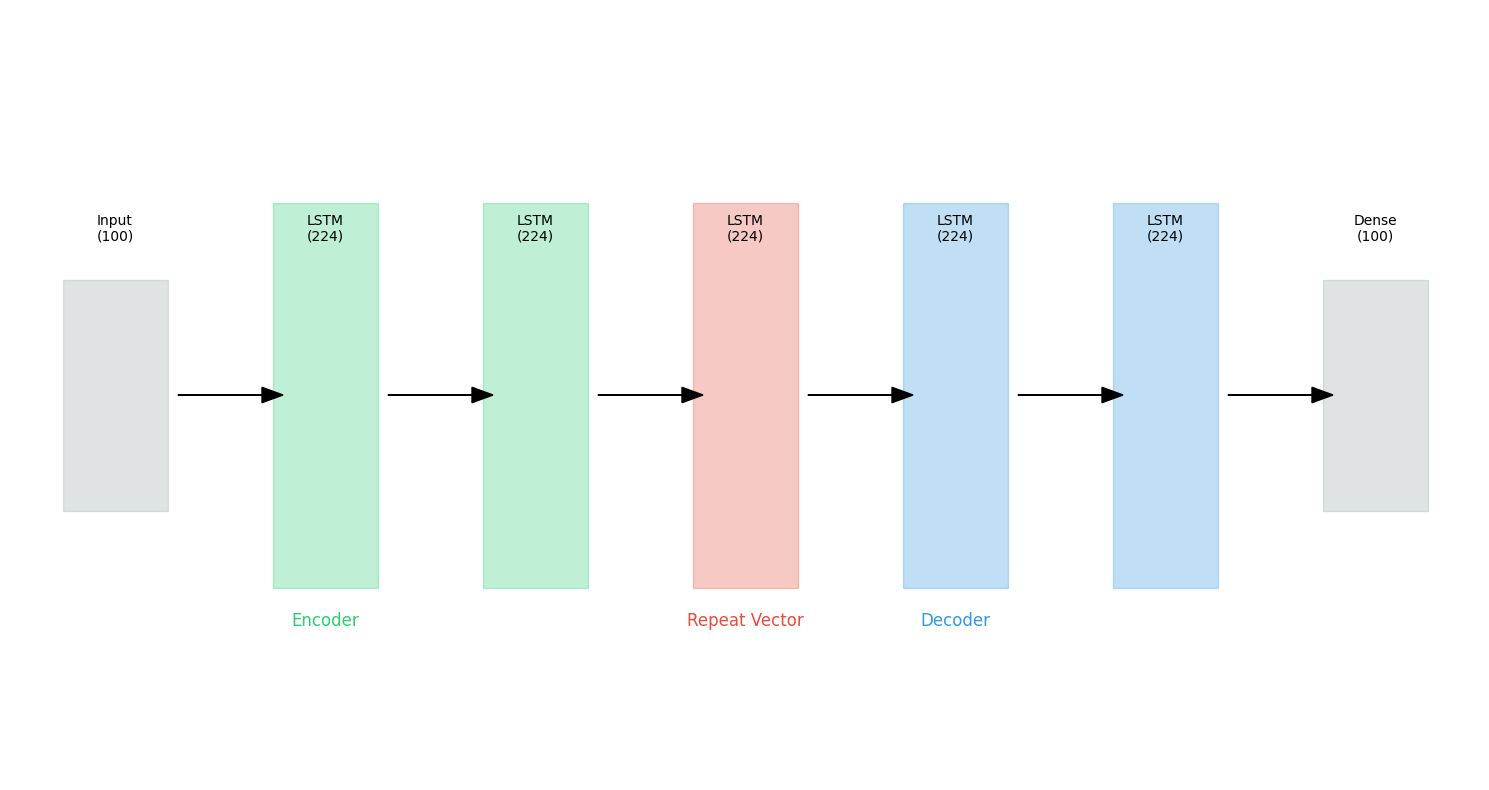

In [9]:
def draw_lstm_architecture():
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(15, 8))
    
    # Define positions
    x_positions = [0, 2, 4, 6, 8, 10, 12]
    y_center = 5
    
    # Colors
    encoder_color = '#2ecc71'  # Green
    decoder_color = '#3498db'  # Blue
    bottleneck_color = '#e74c3c'  # Red
    io_color = '#95a5a6'  # Gray for input/output layers

    # Draw layers
    def draw_layer(x, text, color, is_io=False):
        if is_io:  # Changed is_input to is_io for both input and output
            width, height = 1, 3  # Smaller height for input/output
        else:
            width, height = 1, 5
        rect = plt.Rectangle((x - width/2, y_center - height/2), width, height,
                           facecolor=color, alpha=0.3, edgecolor=color)
        ax.add_patch(rect)
        plt.text(x, y_center + 2, text, ha='center', fontsize=10)
    
    # Input layer
    draw_layer(x_positions[0], f'Input\n(100)', io_color, is_io=True)
    
    # Encoder layers
    draw_layer(x_positions[1], 'LSTM\n(224)', encoder_color)
    draw_layer(x_positions[2], 'LSTM\n(224)', encoder_color)
    
    # Bottleneck layer
    draw_layer(x_positions[3], 'LSTM\n(224)', bottleneck_color)
    
    # Decoder layers
    draw_layer(x_positions[4], 'LSTM\n(224)', decoder_color)
    draw_layer(x_positions[5], 'LSTM\n(224)', decoder_color)
    
    # Output layer - now matches input layer style
    draw_layer(x_positions[6], f'Dense\n(100)', io_color, is_io=True)
    
    # Add arrows
    for i in range(len(x_positions)-1):
        plt.arrow(x_positions[i] + 0.6, y_center, 
                 x_positions[i+1] - x_positions[i] - 1.2, 0,
                 head_width=0.2, head_length=0.2, fc='k', ec='k')
    
    # Customize plot
    #plt.title('LSTM Autoencoder Architecture', pad=20, fontsize=14)
    plt.text(x_positions[1], y_center - 3, 'Encoder', ha='center', fontsize=12, color=encoder_color)
    plt.text(x_positions[3], y_center - 3, 'Repeat Vector', ha='center', fontsize=12, color=bottleneck_color)
    plt.text(x_positions[4], y_center - 3, 'Decoder', ha='center', fontsize=12, color=decoder_color)
    
    # Set limits and remove axes
    plt.xlim(-1, 13)
    plt.ylim(0, 10)
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()

# Call the function to create the visualization
draw_lstm_architecture()

In [9]:
def create_detailed_lstm_architecture(figsize=(12, 8)):
    """Create a detailed visualization of the LSTM architecture"""
    fig, ax = plt.subplots(figsize=figsize)
    
    # Define layer dimensions
    layers = [
        {"name": "Input", "neurons": 100},
        {"name": "LSTM-1", "neurons": 224},
        {"name": "LSTM-2", "neurons": 224},
        {"name": "RepeatVector", "neurons": 224},
        {"name": "LSTM-3", "neurons": 224},
        {"name": "LSTM-4", "neurons": 224},
        {"name": "Output", "neurons": 100}
    ]
    
    # Calculate positions
    horizontal_spacing = 1.5
    max_neurons = max([layer["neurons"] for layer in layers])
    neuron_spacing = 0.8 / max_neurons
    
    # Draw layers
    for i, layer in enumerate(layers):
        x_pos = i * horizontal_spacing
        num_neurons = layer["neurons"]
        
        # Scale the height of the box based on the number of neurons
        height = num_neurons * neuron_spacing
        # Center the box vertically
        y_pos = (0.8 - height) / 2
        
        # Draw the layer box
        color = 'skyblue'
        if layer["name"] == "RepeatVector":
            color = 'tomato'
        elif "LSTM-1" in layer["name"] or "LSTM-2" in layer["name"]:
            color = 'lightgreen'
        elif "LSTM-3" in layer["name"] or "LSTM-4" in layer["name"]:
            color = 'lightsalmon'
        elif layer["name"] in ["Input", "Output"]:
            color = '#95a5a6'
            
        rect = patches.Rectangle((x_pos, y_pos), 0.8, height, linewidth=1, 
                                edgecolor='black', facecolor=color, alpha=0.7)
        ax.add_patch(rect)
        
        # Add layer name and neuron count
        plt.text(x_pos + 0.4, 0.9, f"{layer['name']}\n({layer['neurons']} units)", 
                ha='center', va='center', fontsize=14)
        
        # Draw connections to the next layer
        if i < len(layers) - 1:
            next_layer = layers[i + 1]
            next_height = next_layer["neurons"] * neuron_spacing
            next_y_pos = (0.8 - next_height) / 2
            
            # Draw connections (simplified)
            plt.plot([x_pos + 0.8, (i+1) * horizontal_spacing], 
                    [y_pos + height/2, next_y_pos + next_height/2], 
                    'k-', alpha=0.3)



    # Remove axes
    ax.set_xlim(-0.5, horizontal_spacing * (len(layers) - 1) + 1.5)
    ax.set_ylim(0, 1)
    ax.axis('off')
    
    plt.show()

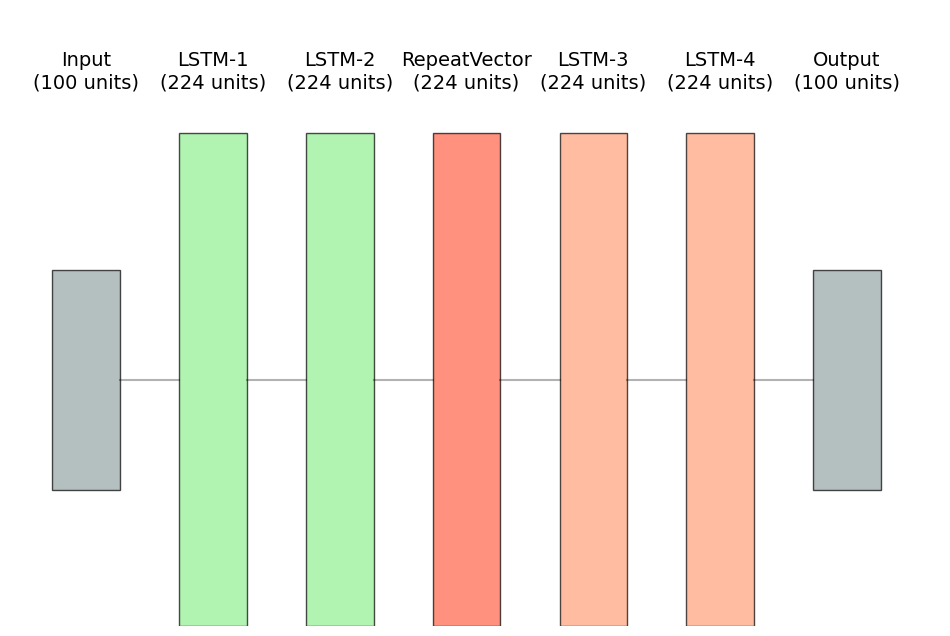

In [10]:
create_detailed_lstm_architecture()